# Reprodução dos modelos do MapBiomas Solo C3 com os climas CHELSA

**Pergunta:** trocando o Köppen IPEF por cada um dos nossos climas, as estimativas de **textura** (areia,
silte, argila) e de **SOC** do MapBiomas Solo melhoram? E como os mapas mudam?

**Resposta curta:**

- **O clima contínuo (12 variáveis CHELSA + balanço hídrico) é a melhor troca para o Köppen**, nas duas
  versões do experimento: melhora o SOC em todas as repetições (+0,014 de R² na versão fiel, +0,023 sem a
  textura da coleção 2) e é o único clima que ajuda a textura de forma apreciável quando o modelo não tem a
  textura anterior (+0,023, sobretudo no silte, +0,038).
- **As zonas climáticas homogêneas (k10) são a segunda melhor opção** e a melhor entre as classificações:
  +0,016 no SOC sem a textura da coleção 2.
- **Com a textura da coleção 2 como covariável (como o MapBiomas faz), a textura não depende do clima:** o
  R² vai a 0,82-0,85 e nenhum clima muda nada — o modelo praticamente copia o produto anterior, que foi
  ajustado com as mesmas amostras. Por isso o experimento foi feito também **sem** essa covariável.
- **Nos mapas, a troca do clima muda pouco a média nacional**, mas redistribui o SOC e a textura em regiões
  específicas (seção 6).

## 1. O que foi reproduzido

| | MapBiomas C3 | Aqui |
|---|---|---|
| **Textura** | GBM por alvo e por camada de 10 cm (horizontes a ±5 cm do centro), sobre ln((x+1)/(argila+1)); profundidade e textura da coleção 2 como covariáveis | igual, nas camadas de 0-30 cm (centros 5, 15 e 25 cm) |
| **SOC** | random forest com a textura de 0-30 cm da coleção atual como covariável; estoque de 0-30 cm | igual; a textura vem do modelo de textura **do mesmo cenário de clima** |
| **Covariáveis** | ~110 (solo, geologia, relevo, bioma, fitofisionomia, uso da terra, índices espectrais, água, fogo) | as mesmas, das matrizes de treino; nos mapas, portadas para Python e conferidas contra a matriz |
| **Clima** | Köppen IPEF em dummies L1-L3 | 9 cenários |

**Cenários de clima:** Köppen IPEF (referência), sem clima, Köppen CHELSA, Holdridge (ETP Penman e ETP de
Holdridge), Thornthwaite (CAD 100 mm e CAD do solo), clima contínuo (12 variáveis) e zonas climáticas
homogêneas (k-means, 10 zonas). As classificações entram em dummies, como o Köppen no MapBiomas.

**Diferenças em relação ao pipeline deles:**
- **Matriz de SOC:** esta conta não tem leitura da matriz de produção (`c03_soc_v2025_11_26_trep`); usamos a
  `matriz-collection3_carbon_datac2v2` (uma linha por local, estoque de 0-30 cm).
- **GBM:** o do scikit-learn (400 iterações, taxa 0,01, 25 folhas), sem a subamostragem de 0,632 do GEE.
- **Mapas:** numa grade de 0,05° (~5 km) alinhada ao CHELSA, com as covariáveis do centro de cada pixel; SOC
  para 2023.

## 2. Como os climas foram comparados

**Validação cruzada em blocos espaciais de 2°** (5 dobras × 3 repetições). Em cada repetição, textura e SOC
usam **as mesmas dobras**, e todos os cenários também — então a diferença para o Köppen é pareada.

**Sem vazamento na cadeia textura → SOC:** em cada dobra, os modelos de textura são treinados só com os
horizontes dos blocos de treino e depois preveem a textura de 0-30 cm nos locais de SOC. Assim a textura
que entra no SOC dos locais de teste vem de modelos que nunca viram aqueles blocos, como aconteceria num
lugar sem amostra.

**Duas versões:**

- **Fiel:** com os mapas de textura da coleção 2 (`sand/silt/clay_000_030cm`) como covariável, como o
  MapBiomas faz.
- **Sem C2:** sem essas três covariáveis. Os mapas da coleção 2 foram ajustados com praticamente as mesmas
  amostras, então "entregam" a resposta mesmo na validação espacial — o ponto de teste já está embutido
  neles. Sem eles, a validação mede a capacidade real de estimar onde não há amostra, e é aí que a escolha
  do clima aparece.

In [1]:
from pathlib import Path
import os
if not Path('resultados/tabelas').exists() and Path('climas/reproducao/resultados').exists():
    os.chdir('climas/reproducao')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as ml
import rasterio

TAB, FIG = Path('resultados/tabelas'), Path('resultados/figuras')
MAPAS = Path('../dados_reproducao/mapas')
FIG.mkdir(parents=True, exist_ok=True)
VERSOES = {'': 'Fiel (com textura C2)', '_semC2': 'Sem textura C2'}
ROT = {'koppen_ipef': 'Köppen IPEF (ref.)', 'sem_clima': 'Sem clima', 'koppen_chelsa': 'Köppen CHELSA',
       'holdridge_etpm': 'Holdridge ETP Penman', 'holdridge_eth': 'Holdridge ETP Holdridge',
       'th_cad100': 'Thornthwaite CAD 100', 'th_cadsolo': 'Thornthwaite CAD solo',
       'clima_continuo': 'Clima contínuo', 'zonas_k10': 'Zonas k10'}
ORDEM = [k for k in ROT if k != 'koppen_ipef']
TINTA, TINTA2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
COR = {'melhor': '#2a78d6', 'pior': '#eb6834', 'empate': '#8c8c8c'}
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': TINTA2, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white'})

def deltas(suf):
    """ΔR² vs Köppen por repetição: textura (média das 3 camadas) por fração, e SOC."""
    t = pd.read_csv(TAB / f'textura_repeticoes{suf}.csv')
    t = t.groupby(['rep', 'fracao', 'cenario']).r2.mean().unstack('cenario')
    dt = t.sub(t['koppen_ipef'], axis=0)
    s = pd.read_csv(TAB / f'soc_repeticoes{suf}.csv').pivot_table(index='rep', columns='cenario', values='r2')
    ds = s.sub(s['koppen_ipef'], axis=0)
    out = {fr: dt.xs(fr, level='fracao') for fr in ('areia', 'silte', 'argila')}
    out['SOC'] = ds
    return out, t, s

RES = {suf: deltas(suf) for suf in VERSOES}

## 3. R² de referência (Köppen IPEF)

R² fora da amostra do modelo com o Köppen, média das repetições (textura: média das 3 camadas).

In [2]:
ref = pd.DataFrame({
    nome: {**{f'R² {fr}': RES[suf][1]['koppen_ipef'].xs(fr, level='fracao').mean() for fr in ('areia', 'silte', 'argila')},
           'R² log(SOC)': RES[suf][2]['koppen_ipef'].mean()}
    for suf, nome in VERSOES.items()}).T
display(ref.round(3))

,R² areia,R² silte,R² argila,R² log(SOC)
Fiel (com textura C2),0.849,0.837,0.821,0.275
Sem textura C2,0.334,0.316,0.293,0.171


Com a textura da coleção 2, o modelo de textura chega a R² de 0,82-0,85; sem ela, cai para 0,29-0,33.
**Quase todo o desempenho da textura vem do produto anterior**, não das covariáveis ambientais. No SOC, a
queda é menor (0,275 → 0,171), porque a textura entra por meio da cadeia.

## 4. Ganho de cada clima em relação ao Köppen

Cada ponto é a diferença média de R² para o Köppen IPEF; a barra vai do menor ao maior valor entre as 3
repetições. **Azul:** melhor que o Köppen em todas as repetições; **laranja:** pior em todas; **cinza:**
depende do sorteio dos blocos.

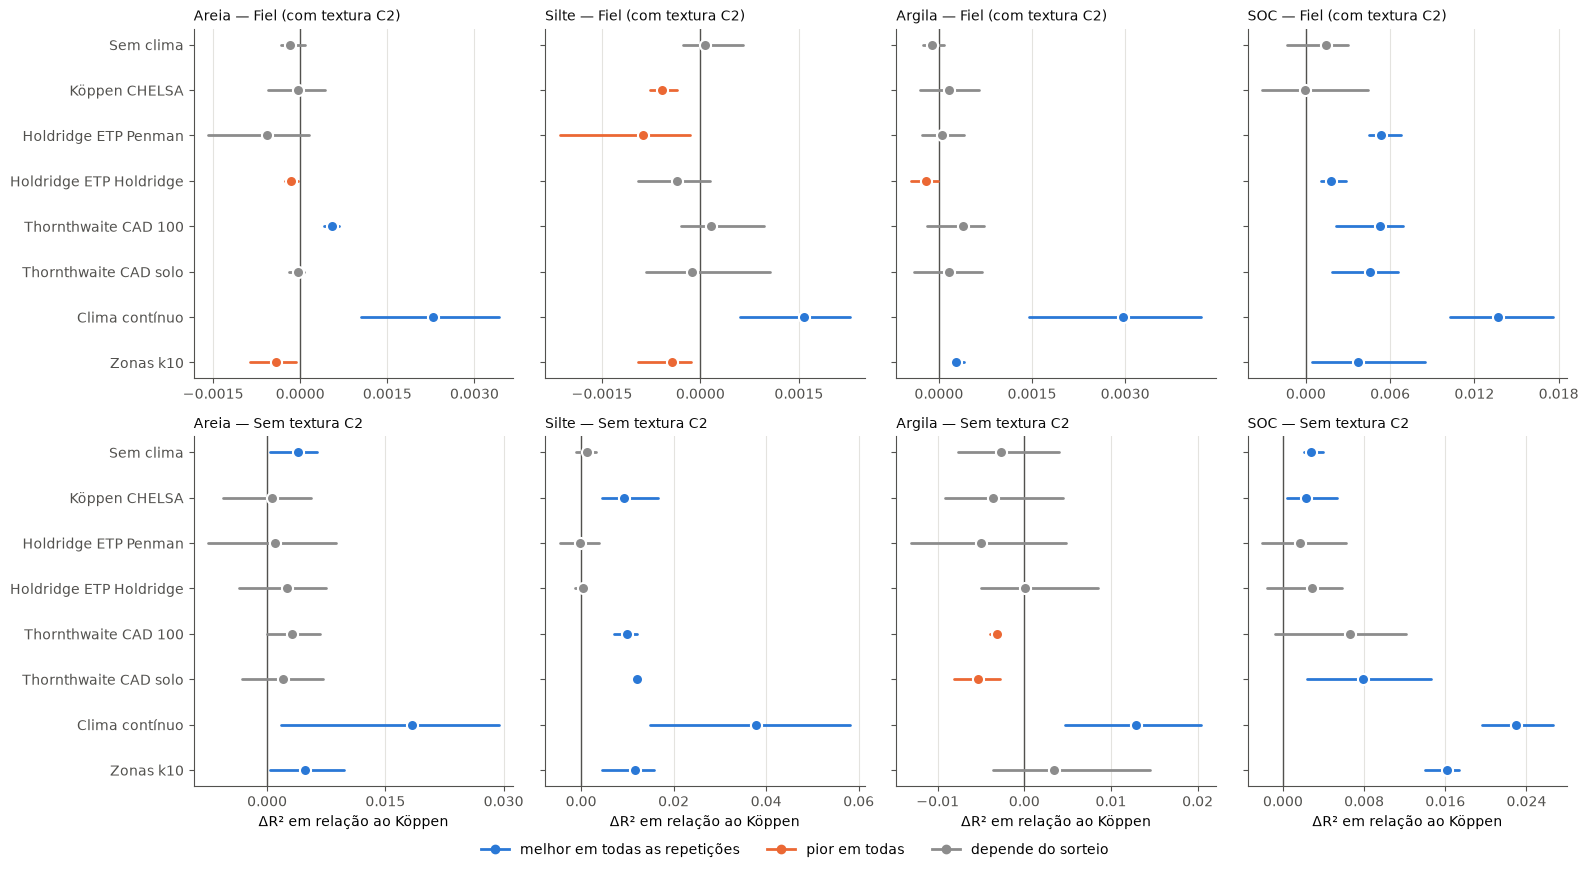

Fiel (com textura C2)                          \
                                        areia   silte  argila     SOC   
Sem clima                             -0.0002  0.0001 -0.0001  0.0014   
Köppen CHELSA                         -0.0000 -0.0006  0.0002 -0.0001   
Holdridge ETP Penman                  -0.0006 -0.0009  0.0001  0.0054   
Holdridge ETP Holdridge               -0.0002 -0.0004 -0.0002  0.0018   
Thornthwaite CAD 100                   0.0006  0.0002  0.0004  0.0053   
Thornthwaite CAD solo                 -0.0000 -0.0001  0.0002  0.0046   
Clima contínuo                         0.0023  0.0016  0.0030  0.0137   
Zonas k10                             -0.0004 -0.0004  0.0003  0.0037   

                        Sem textura C2                          
                                 areia   silte  argila     SOC  
Sem clima                       0.0039  0.0014 -0.0027  0.0027  
Köppen CHELSA                   0.0006  0.0092 -0.0036  0.0023  
Holdridge ETP Penman            0.0010 -0.0002 -0.0050  0.0017  
Holdridge ETP Holdridge         0.0025  0.0005  0.0001  0.0028  
Thornthwaite CAD 100            0.0031  0.0099 -0.0031  0.0066  
Thornthwaite CAD solo           0.0021  0.0121 -0.0053  0.0079  
Clima contínuo                  0.0183  0.0377  0.0129  0.0229  
Zonas k10                       0.0048  0.0116  0.0034  0.0162

In [3]:
ALVOS = ['areia', 'silte', 'argila', 'SOC']
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5), sharey=True)
for lin, (suf, nome) in enumerate(VERSOES.items()):
    for col, alvo in enumerate(ALVOS):
        ax = axes[lin, col]
        d = RES[suf][0][alvo][ORDEM]
        ax.axvline(0, color=TINTA2, lw=1)
        for i, cen in enumerate(ORDEM):
            v = d[cen]; lo, hi, mu = v.min(), v.max(), v.mean()
            cls = 'melhor' if lo > 0 else 'pior' if hi < 0 else 'empate'
            ax.plot([lo, hi], [i, i], color=COR[cls], lw=2, solid_capstyle='round')
            ax.plot(mu, i, 'o', ms=8, color=COR[cls], markeredgecolor='white', markeredgewidth=1.5)
        ax.set_title(f'{alvo if alvo == "SOC" else alvo.capitalize()} — {nome}', loc='left', fontsize=10, color=TINTA)
        ax.grid(axis='x', color=GRADE, lw=0.8)
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        if lin == 1:
            ax.set_xlabel('ΔR² em relação ao Köppen')
axes[0, 0].set_yticks(range(len(ORDEM)), [ROT[c] for c in ORDEM])
axes[0, 0].invert_yaxis()
fig.legend(handles=[ml.Line2D([], [], color=COR[k], marker='o', lw=2, label=l) for k, l in
                    [('melhor', 'melhor em todas as repetições'), ('pior', 'pior em todas'), ('empate', 'depende do sorteio')]],
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout()
fig.savefig(FIG / 'ganho_vs_koppen.png', dpi=130, bbox_inches='tight')
plt.show()

tab = pd.concat({nome: pd.DataFrame({alvo: RES[suf][0][alvo].mean() for alvo in ALVOS}).loc[ORDEM]
                 for suf, nome in VERSOES.items()}, axis=1)
tab.index = [ROT[c] for c in tab.index]
display(tab.round(4))

**Leitura:**

- **Versão fiel:** na textura, as diferenças são mínimas (|ΔR²| ≤ 0,003) — a textura da coleção 2 domina o
  modelo; só o clima contínuo melhora as três frações em todas as repetições, e muito pouco (+0,002 a +0,003). No **SOC**, o **clima contínuo** melhora em todas as repetições (+0,014, ~5% do R²), e quase todas as
  classificações (Holdridge ETP Penman, Thornthwaite, zonas k10) ficam um pouco à frente do Köppen; o Köppen
  CHELSA empata com ele.
- **Sem a textura C2:** o **clima contínuo** é o melhor para textura (+0,023; silte +0,038, areia +0,018,
  argila +0,013 em média), melhorando **as três frações em todas as repetições**, e para SOC (+0,023, ~13%
  do R², em todas as repetições). As **zonas k10** vêm em segundo: SOC +0,016 e areia e silte em todas as
  repetições. O Thornthwaite melhora o silte, mas piora a argila; os demais climas variam com o sorteio dos
  blocos.
- **Holdridge e os dois Köppen ficam perto de zero** nas duas versões.

## 5. Mapas de referência (Köppen IPEF) e com o clima contínuo

Estoque de SOC de 0-30 cm em 2023 (t/ha) e argila de 0-30 cm (%), versão fiel, grade de ~5 km.

/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_7112/2605518412.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return r.read(banda), r.bounds


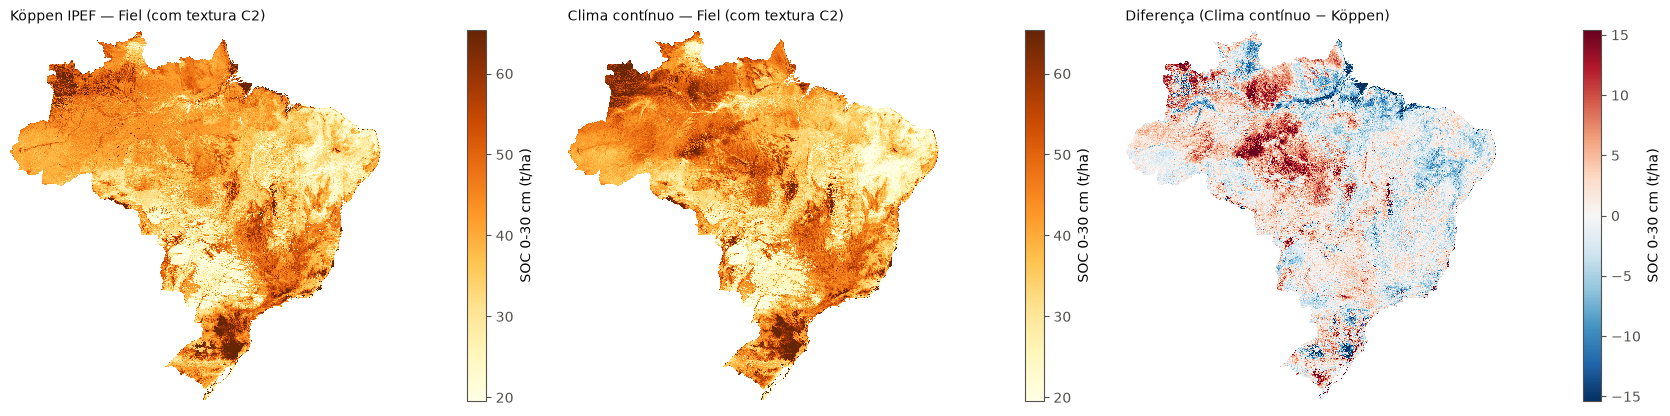

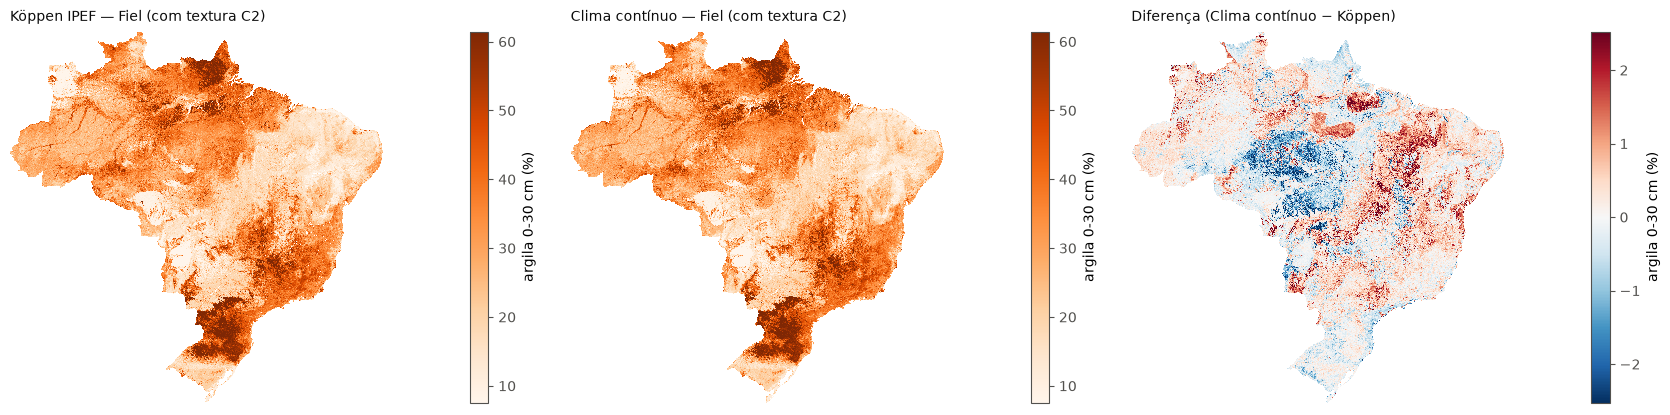

In [4]:
def ler(nome, banda=1):
    with rasterio.open(MAPAS / nome) as r:
        return r.read(banda), r.bounds

def mapa(ax, arr, bounds, titulo, cmap, vmin, vmax, rotulo):
    ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    im = ax.imshow(np.ma.masked_invalid(arr), cmap=cmap, vmin=vmin, vmax=vmax, extent=ext, interpolation='nearest')
    ax.set_title(titulo, loc='left', fontsize=10, color=TINTA)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    plt.colorbar(im, ax=ax, shrink=0.7, label=rotulo)

def trio(prefixo, banda, rotulo, cmap, suf, cen='clima_continuo', lim_dif=None):
    a, b = ler(f'{prefixo}_koppen_ipef{suf}.tif', banda)
    c_, _ = ler(f'{prefixo}_{cen}{suf}.tif', banda)
    lo, hi = np.nanpercentile(np.concatenate([a[np.isfinite(a)], c_[np.isfinite(c_)]]), [2, 98])
    dif = c_ - a
    lim = lim_dif or np.nanpercentile(np.abs(dif), 98)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
    mapa(axes[0], a, b, f'Köppen IPEF — {VERSOES[suf]}', cmap, lo, hi, rotulo)
    mapa(axes[1], c_, b, f'{ROT[cen]} — {VERSOES[suf]}', cmap, lo, hi, rotulo)
    mapa(axes[2], dif, b, f'Diferença ({ROT[cen]} − Köppen)', 'RdBu_r', -lim, lim, rotulo)
    fig.tight_layout()
    return fig

f = trio('soc_0_30cm', 1, 'SOC 0-30 cm (t/ha)', 'YlOrBr', '')
f.savefig(FIG / 'mapa_soc_fiel.png', dpi=110, bbox_inches='tight'); plt.show()
f = trio('textura_0_30cm', 3, 'argila 0-30 cm (%)', 'Oranges', '')
f.savefig(FIG / 'mapa_argila_fiel.png', dpi=110, bbox_inches='tight'); plt.show()

Na versão fiel, os mapas com o Köppen e com o clima contínuo são muito parecidos na escala nacional. A
diferença de SOC (terceiro painel) chega a ±15 t/ha em regiões específicas: com o clima contínuo, o SOC
**aumenta** no arco Rondônia–Mato Grosso–sul do Amazonas e **diminui** no litoral norte (Amapá, Maranhão) e
em partes do Nordeste. Na argila, a diferença é pequena (até ~2 pontos percentuais), porque a textura da
coleção 2 domina o modelo: um pouco menos argila no arco Rondônia–Mato Grosso, um pouco mais em faixas do
Centro-Norte.

## 6. Onde cada clima muda o SOC (versão sem textura C2)

Diferença do SOC previsto (t/ha) em relação ao Köppen IPEF, para cada cenário. Mesma escala de cores em
todos os painéis: **azul** = menos carbono que com o Köppen, **vermelho** = mais.

/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_7112/2605518412.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return r.read(banda), r.bounds


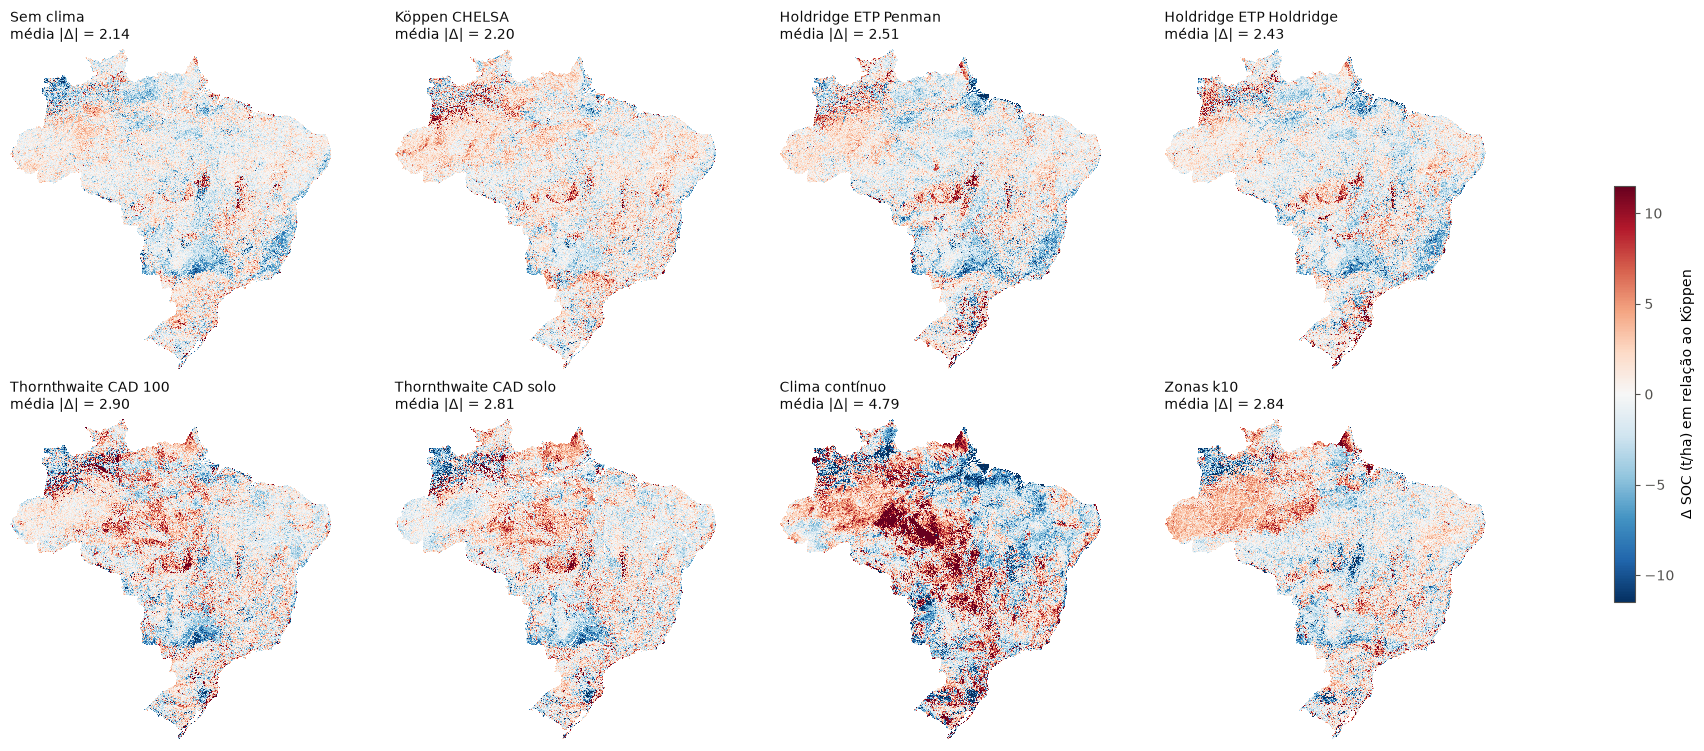

In [5]:
def painel_diferencas(prefixo, banda, rotulo, suf):
    ref, b = ler(f'{prefixo}_koppen_ipef{suf}.tif', banda)
    difs = {cen: ler(f'{prefixo}_{cen}{suf}.tif', banda)[0] - ref for cen in ORDEM}
    lim = np.nanpercentile(np.abs(np.concatenate([d[np.isfinite(d)] for d in difs.values()])), 98)
    fig, axes = plt.subplots(2, 4, figsize=(17, 7.4), layout='constrained')
    for ax, (cen, d) in zip(axes.ravel(), difs.items()):
        ext = [b.left, b.right, b.bottom, b.top]
        im = ax.imshow(np.ma.masked_invalid(d), cmap='RdBu_r', vmin=-lim, vmax=lim, extent=ext, interpolation='nearest')
        ax.set_title(f'{ROT[cen]}\nmédia |Δ| = {np.nanmean(np.abs(d)):.2f}', loc='left', fontsize=10, color=TINTA)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
    fig.colorbar(im, ax=axes, shrink=0.6, label=f'Δ {rotulo} em relação ao Köppen')
    return fig

f = painel_diferencas('soc_0_30cm', 1, 'SOC (t/ha)', '_semC2')
f.savefig(FIG / 'dif_soc_semC2.png', dpi=110, bbox_inches='tight'); plt.show()

**Leitura:**

- **"Sem clima" e o Köppen CHELSA são os que menos mudam o mapa** (|Δ| médio ≈ 2,1-2,2 t/ha); Holdridge,
  Thornthwaite e zonas k10 ficam em ≈ 2,4-2,9 t/ha.
- **O clima contínuo é o que mais muda** (≈ 4,8 t/ha): aumenta o SOC no arco Rondônia–Mato Grosso–sul do
  Pará e reduz no litoral norte (Amapá, norte do Pará, Maranhão); no restante do país as diferenças se
  alternam em manchas. As zonas k10 aumentam sobretudo no oeste da Amazônia.
- **Mudar mais não é, por si, melhor** — quem diz qual mapa é mais confiável é a validação da seção 4, onde
  o clima contínuo foi o melhor. Os mapas mostram **onde** a escolha do clima pesa: nas transições climáticas
  e em regiões com poucas amostras, onde o modelo depende mais da informação climática.

## 7. Onde cada clima muda a argila (versão sem textura C2)

Sem a textura da coleção 2, a argila passa a depender das covariáveis ambientais, e a escolha do clima muda
mais o mapa: |Δ| médio de ≈ 1,1-1,6 pontos percentuais nas classificações e ≈ 2,9 com o clima contínuo, com
diferenças espalhadas pelo Brasil Central e pelo Nordeste.

/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_7112/2605518412.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return r.read(banda), r.bounds


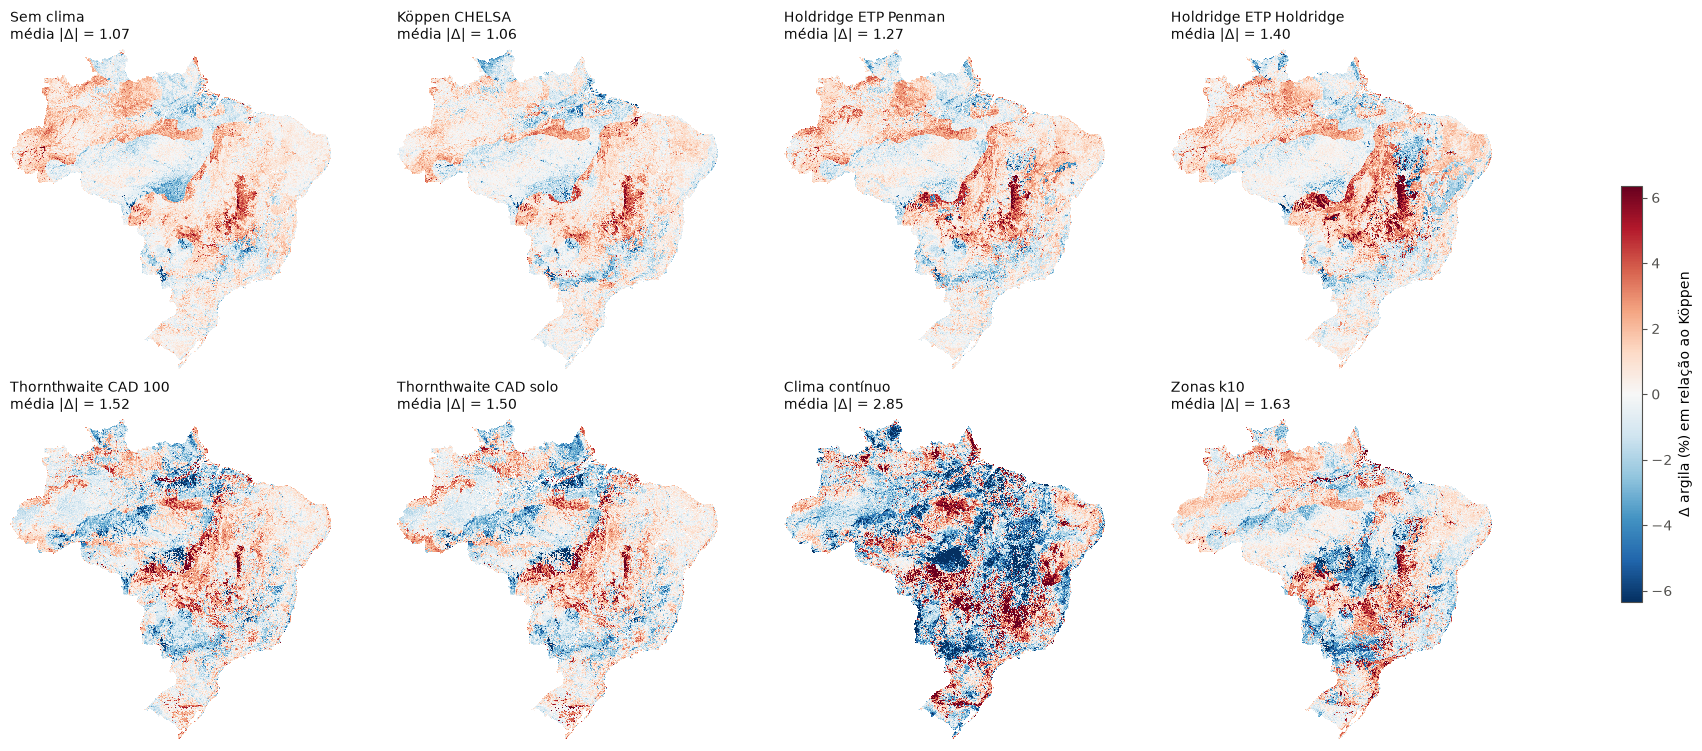

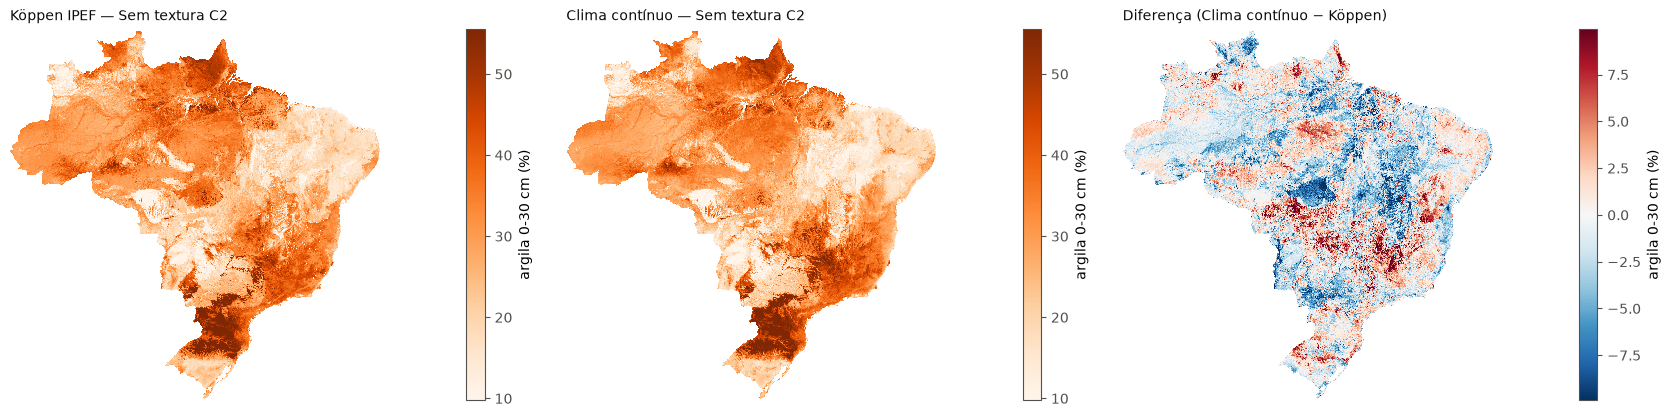

In [6]:
f = painel_diferencas('textura_0_30cm', 3, 'argila (%)', '_semC2')
f.savefig(FIG / 'dif_argila_semC2.png', dpi=110, bbox_inches='tight'); plt.show()
f = trio('textura_0_30cm', 3, 'argila 0-30 cm (%)', 'Oranges', '_semC2')
f.savefig(FIG / 'mapa_argila_semC2.png', dpi=110, bbox_inches='tight'); plt.show()

## 8. Conclusão

1. **Para os modelos do MapBiomas, a melhor troca do Köppen é o clima contínuo** (12 variáveis do CHELSA e
   do balanço hídrico, todas já em assets no GEE). É o único cenário que melhora o SOC em todas as repetições
   nas duas versões e o que mais ajuda a textura quando o modelo não depende do produto anterior.
2. **Se for preciso uma covariável categórica, as zonas climáticas k10** são a melhor classificação —
   segunda melhor opção no geral.
3. **Com a textura da coleção 2 como covariável, o clima não importa para a textura.** Isso não é um mérito
   do modelo: significa que a textura atual quase repete a anterior. Vale discutir com a equipe do MapBiomas
   se essa covariável deve continuar, porque ela esconde a contribuição de todas as outras e infla a
   validação.
4. **Os ganhos são modestos em valor absoluto**, porque o clima é uma entre ~110 covariáveis e bioma,
   fitofisionomia e índices espectrais já carregam parte do sinal climático.

**Limitações:** matriz de SOC não é a de produção; GBM do scikit-learn sem subamostragem; mapas a ~5 km
(o mapa a 30 m do cenário escolhido pode ser gerado no GEE); amostra concentrada em Rondônia e no RS.

## 9. Como reproduzir

```bash
cd codigo
python dados.py                            # GEE (matrizes restritas) + climas da corelacao
./rodar.sh                                 # fase 1 (textura, SOC) e mapas, versão fiel
REPRODUCAO_SEM_C2=1 ./rodar.sh             # idem, sem a textura da coleção 2
python notebook_resultados.py              # regenera este notebook
```

Tabelas agregadas em `resultados/tabelas/`, figuras em `resultados/figuras/`; dados por ponto e mapas
(GeoTIFF) em `../dados_reproducao/` (fora do git).